In [1]:
import pandas as pd 
from matplotlib import pyplot as plt 
import seaborn as sns 
import numpy as np
import plotly.express as px

# Описание Файлов:

 olist_customers_dataset.csv — таблица с уникальными идентификаторами пользователей

1. customer_id — позаказный идентификатор пользователя

1. customer_unique_id — уникальный идентификатор пользователя (аналог номера паспорта)

2. customer_zip_code_prefix — почтовый индекс пользователя

3. customer_city — город доставки пользователя

4. customer_state — штат доставки пользователя

olist_orders_dataset.csv —  таблица заказов

1. order_id — уникальный идентификатор заказа (номер чека)

2. customer_id — позаказный идентификатор пользователя

3. order_status — статус заказа

4. order_purchase_timestamp — время создания заказа

5. order_approved_at — время подтверждения оплаты заказа

6. order_delivered_carrier_date — время передачи заказа в логистическую службу

7. order_delivered_customer_date — время доставки заказа

8. order_estimated_delivery_date — обещанная дата доставки

olist_order_items_dataset.csv — товарные позиции, входящие в заказы


1. order_id — уникальный идентификатор заказа (номер чека)

2. order_item_id — идентификатор товара внутри одного заказа

3. product_id — ид товара (аналог штрихкода)

4. seller_id — ид производителя товара

5. shipping_limit_date — максимальная дата доставки продавцом для передачи заказа партнеру по логистике

6. price — цена за единицу товара

7. freight_value — вес товара 

Пример структуры данных можно визуализировать по order_id == 00143d0f86d6fbd9f9b38ab440ac16f5

Уникальные статусы заказов в таблице olist_orders_dataset:

created — создан;
approved — подтверждён;
invoiced — выставлен счёт;
processing — в процессе сборки заказа;
shipped — отгружён со склада;
delivered — доставлен пользователю;
unavailable — заказ отменён по причине недоступности товара;;
canceled — отменён.

In [3]:
orders = pd.read_csv('olist_orders_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')

# Рассмотрим подробнее orders

In [4]:
orders.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [5]:
orders.order_status.value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [6]:
orders.dtypes

order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

In [7]:
orders.iloc[:,3:].columns

Index(['order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date'],
      dtype='object')

In [8]:
for column in orders.iloc[:,3:].columns:
    orders[column] = pd.to_datetime(orders[column])
orders.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [9]:
orders.order_status.value_counts(normalize=True)

order_status
delivered      0.970203
shipped        0.011132
canceled       0.006285
unavailable    0.006124
invoiced       0.003158
processing     0.003027
created        0.000050
approved       0.000020
Name: proportion, dtype: float64

# Есть ли у нас несоответствия между статусом заказа и датами? 


In [10]:
orders.query('order_status not in ["unavailable","canceled"]').isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  19
order_delivered_carrier_date      624
order_delivered_customer_date    1737
order_estimated_delivery_date       0
dtype: int64

In [11]:
orders.query("order_status == 'processing' and order_approved_at.isna()") 


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date


Всё отлично, собираемые заказы уже оплачены

In [12]:
orders.query("order_status == 'shipped' and order_delivered_carrier_date.isna()") 


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date


Всё отлично, данные по датам отгрузки у нас также есть

In [13]:
orders.query("order_status == 'delivered' and order_delivered_customer_date.isna()")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaT,2017-12-18
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaT,2018-07-16
43834,2ebdfc4f15f23b91474edf87475f108e,29f0540231702fda0cfdee0a310f11aa,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaT,2018-07-30
79263,e69f75a717d64fc5ecdfae42b2e8e086,cfda40ca8dd0a5d486a9635b611b398a,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,2018-07-03 13:57:00,NaT,2018-07-30
82868,0d3268bad9b086af767785e3f0fc0133,4f1d63d35fb7c8999853b2699f5c7649,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaT,2018-07-24
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaT,NaT,2017-06-23
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,dd1b84a7286eb4524d52af4256c0ba24,delivered,2018-06-08 12:09:39,2018-06-08 12:36:39,2018-06-12 14:10:00,NaT,2018-06-26
98038,20edc82cf5400ce95e1afacc25798b31,28c37425f1127d887d7337f284080a0f,delivered,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00,NaT,2018-07-19


А вот тут у меня вопросы, если заказ доставлен, то почему нет даты доставки? 


# Поработаем с Customers

In [14]:
customers.isna().sum() # Всё отличо 

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

# Поработаем с Order_items

In [15]:
order_items.dtypes

order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object

In [16]:
order_items.isna().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [17]:
order_items['shipping_limit_date'] = pd.to_datetime(order_items.shipping_limit_date) 

In [18]:
order_items.dtypes

order_id                       object
order_item_id                   int64
product_id                     object
seller_id                      object
shipping_limit_date    datetime64[ns]
price                         float64
freight_value                 float64
dtype: object

In [19]:
order_items.groupby('seller_id').price.sum().sort_values(ascending=False).head(10)

seller_id
4869f7a5dfa277a7dca6462dcf3b52b2    229472.63
53243585a1d6dc2643021fd1853d8905    222776.05
4a3ca9315b744ce9f8e9374361493884    200472.92
fa1c13f2614d7b5c4749cbc52fecda94    194042.03
7c67e1448b00f6e969d365cea6b010ab    187923.89
7e93a43ef30c4f03f38b393420bc753a    176431.87
da8622b14eb17ae2831f4ac5b9dab84a    160236.57
7a67c85e85bb2ce8582c35f2203ad736    141745.53
1025f0e2d44d7041d6cf58b6550e0bfa    138968.55
955fee9216a65b617aa5c0531780ce60    135171.70
Name: price, dtype: float64

In [20]:
order_items.groupby('seller_id').order_id.nunique().sort_values(ascending=False)

seller_id
6560211a19b47992c3666cc44a7e94c0    1854
4a3ca9315b744ce9f8e9374361493884    1806
cc419e0650a3c5ba77189a1882b7556a    1706
1f50f920176fa81dab994f9023523100    1404
da8622b14eb17ae2831f4ac5b9dab84a    1314
                                    ... 
cb810bd318f51b3dc3c753944d61a1fa       1
cb4a705d00e100b9732d0ca34817d441       1
cd233f8bfa30ebfd651f47ee7d054951       1
cd2169d9f31ff6fbb9ca3373b0c9e354       1
ccbd753e6863fe7314dc6c0ca5a074e7       1
Name: order_id, Length: 3095, dtype: int64

# Задача 1. Оценить месячный retention в оформление заказа с помощью когортного анализа.

In [21]:
(customers.groupby('customer_unique_id').customer_id.nunique() > 1).sum()

np.int64(2997)

In [22]:
(orders.groupby('customer_id').order_id.nunique()>1).sum()

np.int64(0)

Для каждого customer_id есть 1 order_id, retention мы будем смотреть по unique_customer_id  

In [23]:
customers_orders = pd.merge(orders,customers,on='customer_id')

Создаём колнку первого заказа для каждого клиента, используем transform для корректного создания колонки

In [24]:
customers_orders['cohort'] = customers_orders.groupby('customer_unique_id')['order_purchase_timestamp'] \
.transform('min').dt.to_period('m')
customers_orders['cohort_day'] = customers_orders.groupby('customer_unique_id')['order_purchase_timestamp'] \
.transform('min').dt.to_period('d')

C:\Users\danii\AppData\Local\Temp\ipykernel_8484\1853836004.py:2: FutureWarning: 'm' is deprecated and will be removed in a future version, please use 'M' instead.
  .transform('min').dt.to_period('m')


In [30]:
customers_orders.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
customer_unique_id                       object
customer_zip_code_prefix                  int64
customer_city                            object
customer_state                           object
cohort                                period[M]
cohort_day                            period[D]
dtype: object

Для своего удобства выведу необходимые данные в отдельный датафрейм

In [31]:
df_to_retention = customers_orders[['customer_unique_id','cohort','cohort_day','order_purchase_timestamp','order_status','customer_city','customer_state','order_id']].copy()


In [32]:
df_to_retention['purchase_day'] = df_to_retention.order_purchase_timestamp.dt.to_period('d')

In [33]:
df_to_retention['period'] = np.floor(((df_to_retention['purchase_day'] - df_to_retention['cohort_day']).apply(lambda x: x.n))/30)
df_to_retention.head()

,customer_unique_id,cohort,cohort_day,order_purchase_timestamp,order_status,customer_city,customer_state,order_id,purchase_day,period
0,7c396fd4830fd04220f754e42b4e5bff,2017-09,2017-09-04,2017-10-02 10:56:33,delivered,sao paulo,SP,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02,0.0
1,af07308b275d755c9edb36a90c618231,2018-07,2018-07-24,2018-07-24 20:41:37,delivered,barreiras,BA,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24,0.0
2,3a653a41f6f9fc3d2a113cf8398680e8,2018-08,2018-08-08,2018-08-08 08:38:49,delivered,vianopolis,GO,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08,0.0
3,7c142cf63193a1473d2e66489a9ae977,2017-11,2017-11-18,2017-11-18 19:28:06,delivered,sao goncalo do amarante,RN,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18,0.0
4,72632f0f9dd73dfee390c9b22eb56dd6,2018-02,2018-02-13,2018-02-13 21:18:39,delivered,santo andre,SP,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13,0.0


# Какой вид заказа использовать для расчёта retention?

Исходя из того факта, что для одного заказа есть только один статус я принял решение учитывать все заказы, даже отменённые самим пользователям. Отменённые заказы озночают, что пользователи помнят о приложении, но могут отменить их по своим причинам (дата доставки, передумал и тд.), для полного анализа нам потребовались бы дополнительные данные 


# Мы видим что возвращаемость пользователя сильно падает

Text(0, 0.5, 'Доля вернувшихся')

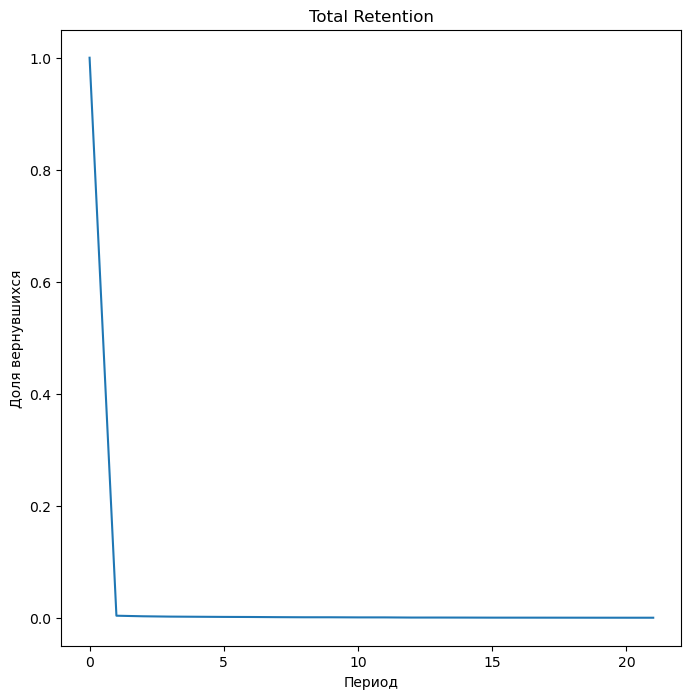

In [40]:
plt.figure(figsize=(8,8))
sns.lineplot(data=(df_to_retention.period.value_counts() / df_to_retention.period.value_counts()[0]))
plt.title('Total Retention')
plt.xlabel('Период')
plt.ylabel('Доля вернувшихся')

In [41]:
retention = df_to_retention.groupby(['cohort','period'],as_index=False).customer_unique_id.nunique()
retention_pivot =retention.pivot(index='cohort',columns='period',values='customer_unique_id').fillna(0)
#Если значений нет, то значит заказов не было 
first = retention_pivot.iloc[:,0]

retention_pivot_p=retention_pivot.divide(first,axis=0)
retention_pivot_p

period,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,11.0,12.0,13.0,14.0,15.0,16.0,17.0,19.0,20.0,21.0
cohort,,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2016-10,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.003115,0.000000,0.000000,0.003115,...,0.003115,0.000000,0.003115,0.000000,0.003115,0.000000,0.003115,0.006231,0.003115,0.003115
2016-12,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2017-01,1.0,0.002618,0.000000,0.005236,0.001309,0.001309,0.003927,0.002618,0.000000,0.000000,...,0.006545,0.003927,0.002618,0.000000,0.002618,0.002618,0.002618,0.001309,0.000000,0.000000
2017-02,1.0,0.001712,0.001712,0.003425,0.002283,0.001142,0.002283,0.001142,0.001142,0.002854,...,0.003425,0.001142,0.001712,0.001142,0.000571,0.001142,0.002283,0.000000,0.000000,0.000000
2017-03,1.0,0.002656,0.005311,0.004173,0.001138,0.000759,0.003414,0.001517,0.002656,0.002276,...,0.001897,0.001897,0.001138,0.002656,0.000759,0.001138,0.001138,0.000000,0.000000,0.000000
2017-04,1.0,0.003401,0.002551,0.000425,0.003401,0.003401,0.002551,0.004252,0.002126,0.002551,...,0.001701,0.000000,0.000850,0.000850,0.000850,0.001701,0.000000,0.000000,0.000000,0.000000
2017-05,1.0,0.004449,0.004171,0.003337,0.003615,0.003337,0.003337,0.001390,0.003059,0.002781,...,0.003059,0.001947,0.001112,0.002503,0.001390,0.000000,0.000000,0.000000,0.000000,0.000000
2017-06,1.0,0.004141,0.004460,0.003823,0.001274,0.005097,0.003186,0.001911,0.001274,0.003504,...,0.002549,0.000637,0.002549,0.000956,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


Text(120.72222222222221, 0.5, 'Когорта')

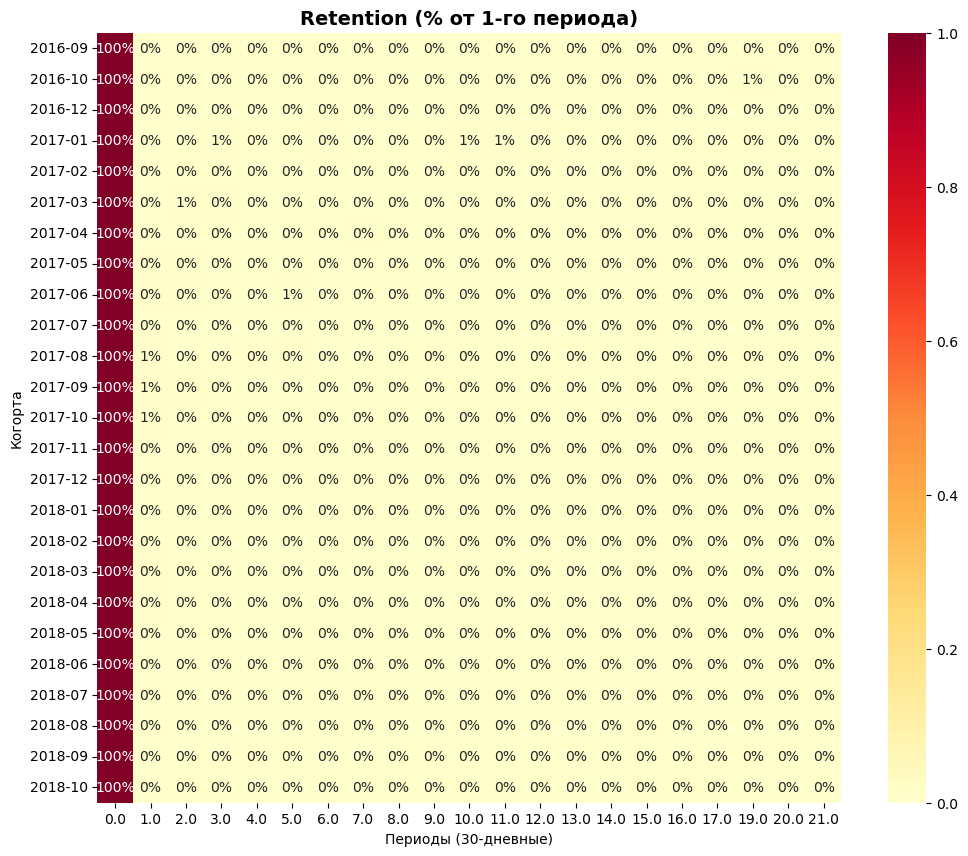

In [42]:
plt.figure(figsize=(12,10))
sns.heatmap(retention_pivot_p,annot=True, cmap='YlOrRd',fmt='.0%')
plt.title('Retention (% от 1-го периода)', fontsize=14, fontweight='bold')
plt.xlabel('Периоды (30-дневные)')
plt.ylabel('Когорта')


In [43]:
df_to_retention.query('period != 0.0').customer_unique_id.count()

np.int64(1740)

In [44]:
customers_orders.customer_unique_id.count()

np.int64(99441)

На данном этапе анализа мы видим катострофическую ситуацию

Достаточно большой поток клиентов делает заказы только в первый месяц, повторные же заказы скорее являются сюрпризом, а не закономерностью 

Из 99441 заказа всего 1740 являются повторными 

# Приведем несколько гипотез причины такого большого оттока 

1. Просрочки по доставке 

In [45]:
df = orders[['order_id','order_purchase_timestamp','order_delivered_customer_date','order_estimated_delivery_date','order_delivered_carrier_date']].copy()
df
(df.query('order_estimated_delivery_date < order_delivered_customer_date').shape[0] / df.shape[0])*100

7.870998883760219

7% заказов пришли с просрочкой
Не думаю что это ключевая причина такого большого оттока

In [46]:
((df.order_delivered_customer_date - df.order_purchase_timestamp).dt.days).describe()

count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
dtype: float64

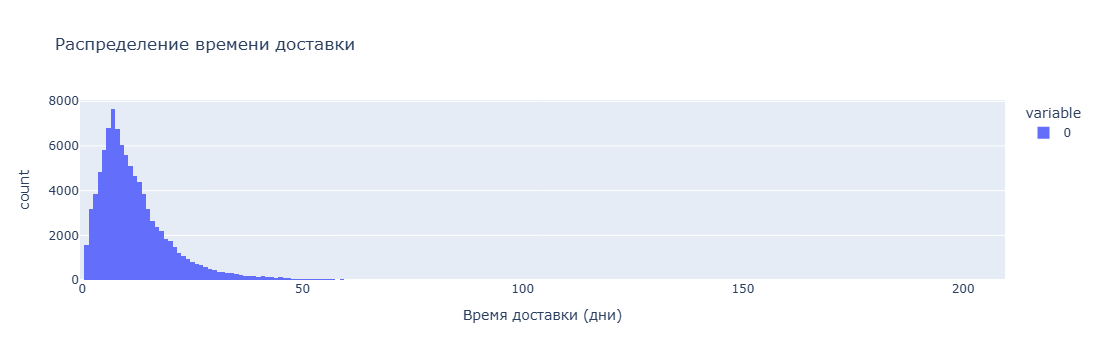

In [79]:
delivery_days = (df.order_delivered_customer_date - df.order_purchase_timestamp).dt.days

# Строим гистограмму
fig = px.histogram(
    delivery_days,
    title='Распределение времени доставки',
    labels={'value': 'Время доставки (дни)', 'count': 'Количество заказов'}
)

fig.show()

А вот среднее время доставки товара для маркетплейсов превышает норму в сравнении с главными конкурентами (к примеру норма 2-3 дня)

Да и при рассмотрении распределения дней доставки мы видим, что более половины заказов приезжают позже 10 дней

25% заказов приезжают позже 15 дней 

Можно предположить что это является решающим фактором возвращаемости клиента

# Может проблема в штатах?

In [48]:
retention_pivot_states = df_to_retention.groupby(['customer_state','period'],as_index=False).customer_unique_id.nunique() \
.pivot(index='customer_state',columns='period',values='customer_unique_id').fillna(0)
first = retention_pivot_states.iloc[:,0]

retention_states=retention_pivot_states.divide(first,axis=0)
retention_states

period,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,11.0,12.0,13.0,14.0,15.0,16.0,17.0,19.0,20.0,21.0
customer_state,,,,,,,,,,,,,,,,,,,,,
AC,1.0,0.012987,0.000000,0.012987,0.000000,0.000000,0.000000,0.000000,0.000000,0.012987,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
AL,1.0,0.000000,0.000000,0.000000,0.000000,0.002494,0.004988,0.000000,0.002494,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
AM,1.0,0.000000,0.000000,0.000000,0.000000,0.006993,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.006993,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
AP,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
BA,1.0,0.004577,0.002136,0.001526,0.000915,0.001526,0.002441,0.000915,0.000000,0.000000,...,0.000915,0.000305,0.000000,0.000000,0.000305,0.000000,0.000000,0.000000,0.000000,0.000000
CE,1.0,0.004577,0.000763,0.000000,0.000763,0.001526,0.000000,0.000763,0.000000,0.001526,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
DF,1.0,0.003375,0.001929,0.000964,0.000964,0.000964,0.000964,0.000964,0.000000,0.000482,...,0.000000,0.000482,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ES,1.0,0.002038,0.004075,0.000509,0.001019,0.002038,0.000509,0.001019,0.000509,0.001019,...,0.000509,0.000509,0.001019,0.000000,0.000000,0.000509,0.000000,0.000000,0.000000,0.000000
GO,1.0,0.004613,0.003075,0.003075,0.001538,0.002050,0.000513,0.001025,0.000513,0.000513,...,0.001025,0.001025,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000513,0.000000


Text(120.72222222222221, 0.5, 'Штат')

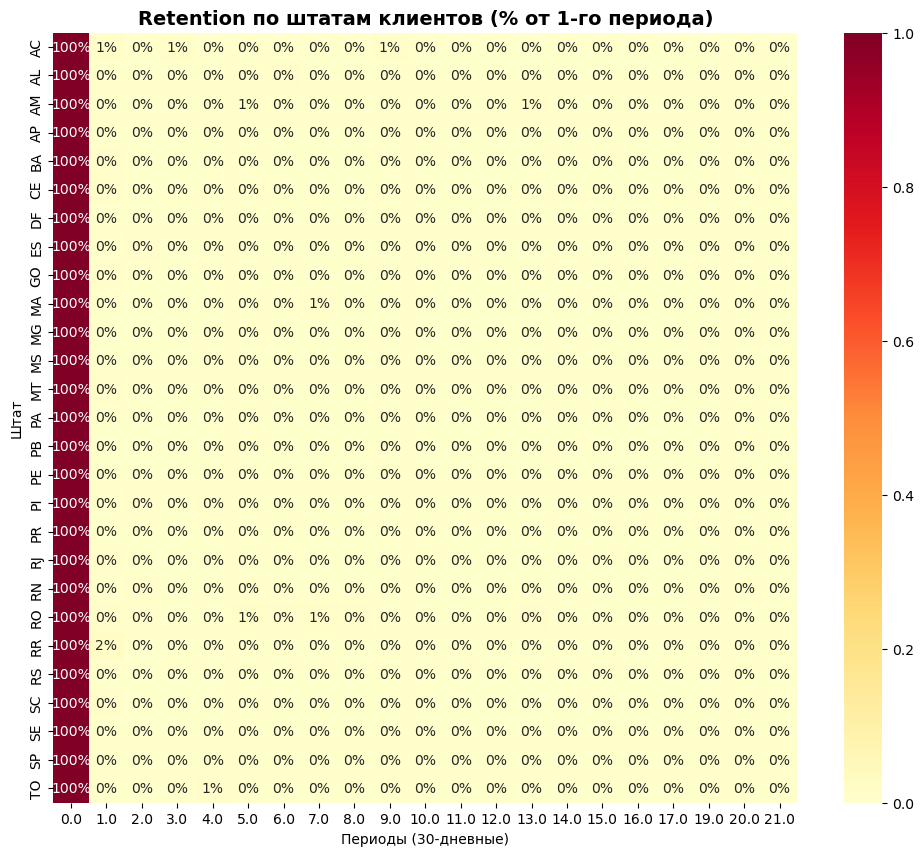

In [49]:
plt.figure(figsize=(12,10))
sns.heatmap(retention_states,annot=True, cmap='YlOrRd',fmt='.0%')
plt.title('Retention по штатам клиентов (% от 1-го периода)', fontsize=14, fontweight='bold')
plt.xlabel('Периоды (30-дневные)')
plt.ylabel('Штат')

Даже при рассмотрении в разрезе штатов retention не показывает ни в одном из них заметного улучшения

# Может быть проблема в продавцах/продуктах? 

In [50]:
df_to_retention_sales = pd.merge(df_to_retention[['customer_unique_id','order_id','cohort','period']],order_items[['order_id','product_id','seller_id']],on='order_id')

In [51]:
retention_pivot_seller = df_to_retention_sales.groupby(['seller_id','period'],as_index=False).customer_unique_id.nunique()\
.pivot(index='seller_id',columns='period',values='customer_unique_id')

first = retention_pivot_seller.iloc[:,0]
retention_pivot_seller.divide(first,axis=0).sort_values(by=1.0,ascending=False).fillna(0)

period,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,11.0,12.0,13.0,14.0,15.0,16.0,17.0,19.0,20.0,21.0
seller_id,,,,,,,,,,,,,,,,,,,,,
1f7fd2a6fcd5a6fa5d8a4dabc72aaae0,1.0,0.500000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
b0f2a6122a90a93eb03e68653dd960e3,1.0,0.500000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
d149de2f383552baea37a7198c2296ce,1.0,0.500000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
262237171f48e85819065498cac80d7b,1.0,0.333333,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
5566627eab3fe93fd6ee08798226101a,1.0,0.250000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ffcfefa19b08742c5d315f2791395ee5,1.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
ffdd9f82b9a447f6f8d4b91554cc7dd3,1.0,0.000000,0.058824,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
ffeee66ac5d5a62fe688b9d26f83f534,1.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0


Даже с учётом того, что у отдельно взятых селлеров retention первого месяца может быть на достаточно высоких позициях, мы видим снижение до нуля при рассмотрении дальнеших периодов

# Проанализировать, чему равен медианный retention 1-го месяца (т.е. взять retention 1-ого месяца для всех когорт и посчитать по этим числам медиану)

In [52]:
retention_pivot_p[1.0].median()

0.003401360544217687

Retention 1-го месяца для всех когорт равен всего 0.3 %

# Найти когорту с самым высоким retention на 3-й месяц.

In [53]:
retention_pivot_p[3.0].sort_values(ascending=False).reset_index().cohort[0]

Period('2017-01', 'M')

Самый высокий retention на 3-й месяц у когорты 2017-01

# Задача 2. Определить, существует ли product/market fit у маркетплейса.


К сожалению у нас нет данных о стоимости привлечения клиента и переменных издержек на клиента, но мы можем выяснить сколько денег приносит нам клиент

In [54]:
df_for_ltv = pd.merge(customers_orders,order_items.groupby('order_id').price.sum().reset_index(),on='order_id')
df_for_ltv = df_for_ltv.query('order_status == "delivered"')


Для расчёта я взял только доставленные заказы, для того чтоб посмотреть сколько денег с заказа мы получаем от пользователя
Логика моя была такова:
1. Если брать заказы с промежуточным статусом, то мы не уверены получим ли мы прибыль с клиента
2. Отменённые заказы я считаю не реализованными, а значит денег с них мы не получили (а даже наоборот получили убыток) 

In [55]:
df_for_ltv.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,cohort,cohort_day,price
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2017-09,2017-09-04,29.99
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,2018-07,2018-07-24,118.70
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,2018-08,2018-08-08,159.90
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,2017-11,2017-11-18,45.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,2018-02,2018-02-13,19.90


In [56]:
mean_price = df_for_ltv.price.mean() # Средняя стоимость заказа 
mean_orders = df_for_ltv.groupby('customer_unique_id').order_id.count().mean()
mean_price*mean_orders # Средняя выручка с заказов на клиента 

np.float64(141.62147978748476)

Даже на данном этапе я могу сказать однозначно что у проекта нет product/market fit 
Клиенты не возвращаются в продукт и не делают достаточно дорогие заказы (для покрытия расходов в условиях малого retenrion) 

# На чём маркетплейс должен сконцентрироватся? 

Ответ однозначный - необходимо повышать возвращаемость пользователей

Также мы не знаем расходов на доставку заказа, но интуитивно понятно что необходимо повышать средний чек

Также среднее время доставки завышено по сравнению с аналогами, возможно это является ключевым фактором оттока клиентов 

# Задача 3. Определить 5 основных метрик, на которых продакт может сконцентрироваться, чтобы максимизировать прибыль компании.
Первая метрика должна отражать рост объёма продаж маркетплейса.
Вторая — показывать объем аудитории, которой продукт доставляет ценность.
Третья — отражать заинтересованность новых клиентов в продукте (даже если вы не можете посчитать ее на имеющихся у вас данных).
Четвёртая — отражать вовлеченность клиента в продолжение использования продукта.
Пятая — отражать денежное выражение вовлеченности клиента.

1 Месячная выручка

С учётом того, что оплату за заказ мы получим при получении заказа клиентом, я беру даты для расчёта выручки в датах доставки 

In [57]:

month_sales = pd.merge(orders.query('order_status=="delivered"')[['order_id','order_delivered_customer_date']], 
                       order_items[['order_id','price']])
month_sales['month'] = month_sales['order_delivered_customer_date'].dt.to_period('M')
monthly_revenue = month_sales.set_index('month').resample('m').price.sum().reset_index()
monthly_revenue['month'] = monthly_revenue['month'].astype('str')
monthly_revenue = monthly_revenue.rename(columns={'price':'revenue'})
monthly_revenue


C:\Users\danii\AppData\Local\Temp\ipykernel_8484\3925098354.py:4: FutureWarning:

'm' is deprecated and will be removed in a future version, please use 'M' instead.

C:\Users\danii\AppData\Local\Temp\ipykernel_8484\3925098354.py:4: FutureWarning:

Resampling with a PeriodIndex is deprecated. Cast index to DatetimeIndex before resampling instead.



,month,revenue
0,2016-10,29874.44
1,2016-11,9837.68
2,2016-12,758.86
3,2017-01,33599.12
4,2017-02,198909.29
5,2017-03,335886.21
6,2017-04,268687.23
7,2017-05,520141.45
8,2017-06,430779.58
9,2017-07,455000.99


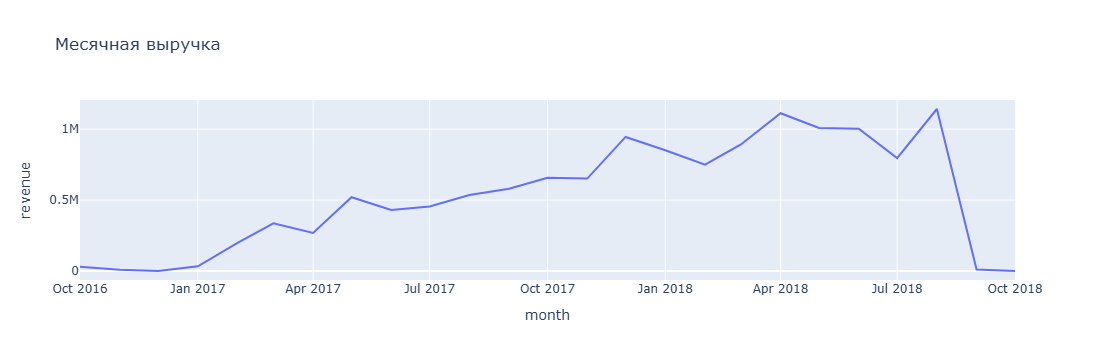

In [58]:
px.line(data_frame=monthly_revenue,x='month',y='revenue',title = 'Месячная выручка')


2. MAU

Объём аудитории мы можем посмотреть по MAU, учитывать будем только тех клиентов, кто оформил заказ и не отменил его
(Заказы отменённые доставкой я всё-равно буду считать по причине того, что они всё-равно показывают желание клиента получить заказ, а вот факт доставки стоит за компанией) 

In [59]:
df_MAU = customers_orders[['order_id','customer_unique_id','order_status','order_purchase_timestamp']].copy()
df_MAU['purchase_month'] = df_MAU.order_purchase_timestamp.dt.to_period('M')
MAU = df_MAU.set_index('purchase_month').resample('M').customer_unique_id.nunique().reset_index() \
.rename(columns={'customer_unique_id':'MAU'})
MAU

C:\Users\danii\AppData\Local\Temp\ipykernel_8484\4065876706.py:3: FutureWarning:

Resampling with a PeriodIndex is deprecated. Cast index to DatetimeIndex before resampling instead.



,purchase_month,MAU
0,2016-09,4
1,2016-10,321
2,2016-11,0
3,2016-12,1
4,2017-01,765
5,2017-02,1755
6,2017-03,2642
7,2017-04,2372
8,2017-05,3625
9,2017-06,3180


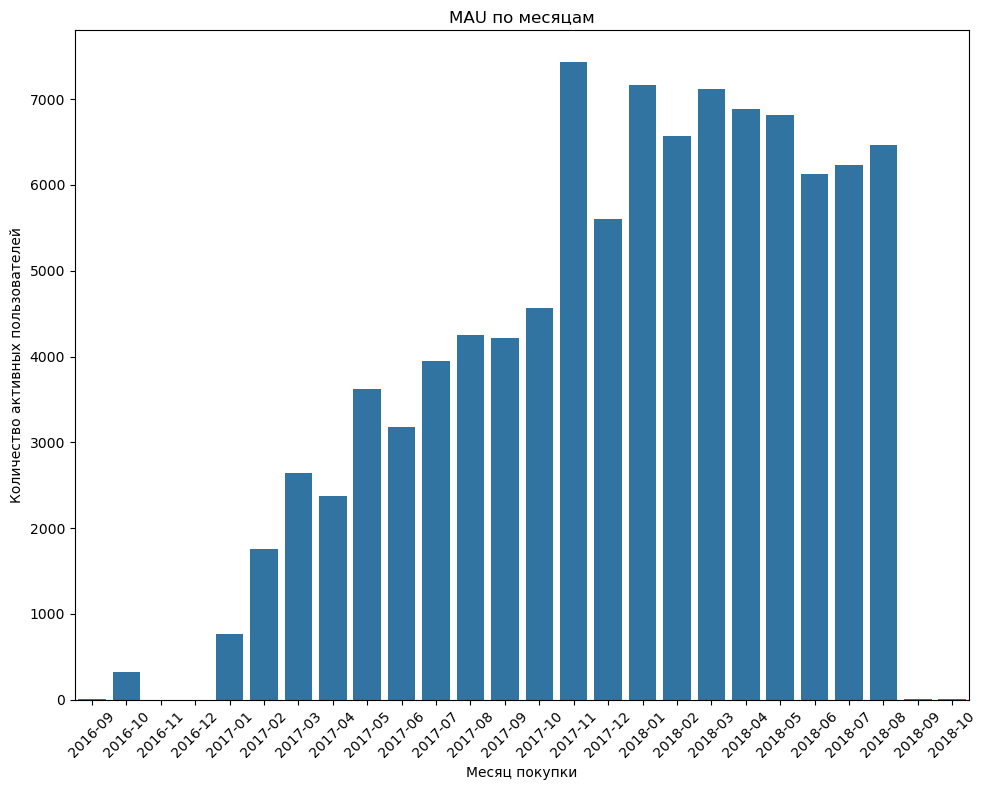

In [60]:
plt.figure(figsize=(10,8))
sns.barplot(data=MAU,x='purchase_month',y='MAU')
plt.xlabel('Месяц покупки')  
plt.ylabel('Количество активных пользователей') 
plt.title('MAU по месяцам')  
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()


2.2 MAU новых пользователей 

In [61]:
df_new_customer = df_MAU.merge(customers_orders[['customer_unique_id','cohort']],on='customer_unique_id') \
.query('cohort==purchase_month').set_index('purchase_month')

new_customer = df_new_customer.resample('M').customer_unique_id.nunique()
new_customer.reset_index()

C:\Users\danii\AppData\Local\Temp\ipykernel_8484\4081110597.py:4: FutureWarning:

Resampling with a PeriodIndex is deprecated. Cast index to DatetimeIndex before resampling instead.



,purchase_month,customer_unique_id
0,2016-09,4
1,2016-10,321
2,2016-11,0
3,2016-12,1
4,2017-01,764
5,2017-02,1752
6,2017-03,2636
7,2017-04,2352
8,2017-05,3596
9,2017-06,3139


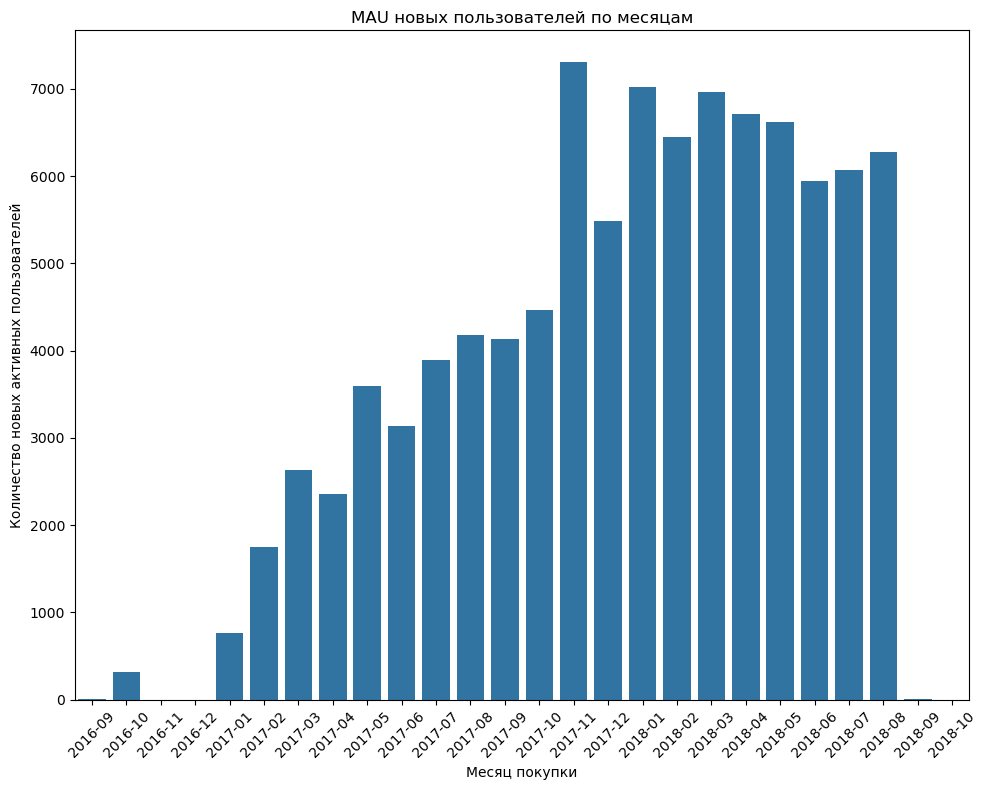

In [62]:
plt.figure(figsize=(10,8))
sns.barplot(data=new_customer.reset_index(),x='purchase_month',y='customer_unique_id')
plt.xlabel('Месяц покупки')  
plt.ylabel('Количество новых активных пользователей') 
plt.title('MAU новых пользователей по месяцам')  
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()


3.  Отражать заинтересованность новых клиентов в продукте мы можем разными способами, интересным способом было бы вычисление доли пользователей совершивих "триггерную активность", к примеру процент пользователей совершивших первый заказ в течении месяца после регистрации 

Либо посмотреть на среднее количество товаров в корзине у новых пользователей в течении месяца (К примеру сравнение двух этих метрик покажет то, что потребители заинтересованы в товарах, но низкий процент купивших будет означать, что есть проблемы с этапом покупки/оформления заказа) 

4. Показать вовлечённость клиента в продукт можно с помощью Retention, который мы расчитывали выше, также можно смотреть на количество пользователей совершивших повторные покупки

In [63]:
repeat = df_to_retention.groupby(['period','customer_unique_id'],as_index=False).order_id.nunique().query('order_id > 1') \
.groupby('period').customer_unique_id.nunique()
repeat = repeat.reset_index()
repeat['period'] = repeat.period.astype('int64')
repeat

,period,customer_unique_id
0,0,1528
1,1,5
2,2,15
3,3,4
4,4,7
5,5,9
6,6,3
7,7,2
8,8,2
9,9,2


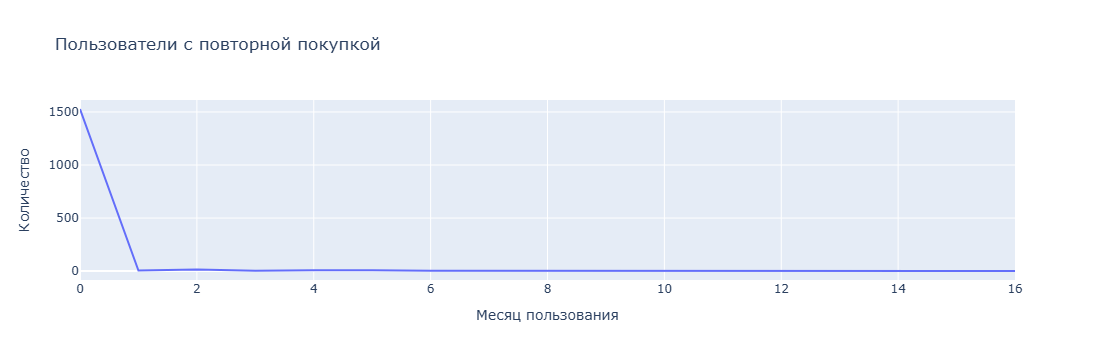

In [64]:
px.line(data_frame= repeat.reset_index(),x='period',y='customer_unique_id',title='Пользователи с повторной покупкой',
        labels={'period':'Месяц пользования','customer_unique_id':'Количество'})


5. Денежное выражение заинтересованности клиентов мы можем выразить при рассмотрении выручки и выручки на клиента
для когорт и периодов.

Также можно использовать LTV, его мы считали выше 

In [65]:
df_for_ltv['order_delivered_month'] = df_for_ltv['order_delivered_customer_date'].dt.to_period('M') 

revenue_cohorts = df_for_ltv[['order_id','customer_unique_id','cohort','cohort_day','order_delivered_customer_date','order_delivered_month','price']].copy()
revenue_cohorts['order_delivered_customer_date'] = revenue_cohorts['order_delivered_customer_date'].dt.to_period('D')
revenue_cohorts = revenue_cohorts.dropna() # Удаляю те строки где нет даты доставки (их мы нашли при провекре датафрейма выше)
revenue_cohorts['period']=(revenue_cohorts['order_delivered_customer_date'] - revenue_cohorts['cohort_day']).apply(lambda x: x.n)//30

revenue_summary = revenue_cohorts.groupby(['cohort','period']).price.agg(['sum','count']).reset_index()

revenue_pivot = revenue_summary.pivot(index='cohort',columns='period',values='sum')
revenue_summary['revenue_per_user'] = revenue_summary['sum']/revenue_summary['count']
revenue_per_user_pivot = revenue_summary.pivot(index='cohort',columns='period',values='revenue_per_user')

Нули в нулевом периоде (извините) в этой таблице нормальны, мы считаем за получение выручки момент доставки клиенту.

In [66]:
revenue_pivot.fillna(0)

period,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
cohort,,,,,,,,,,,,,,,,,,,,,
2016-09,0.00,134.97,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.0,0.00
2016-10,30913.72,8663.43,747.96,0.00,0.00,0.00,99.99,0.00,0.00,0.00,...,49.00,115.20,0.00,298.60,0.00,98.00,0.0,289.28,132.4,25.99
2016-12,21.80,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.0,0.00
2017-01,107309.93,2923.35,1608.39,338.40,149.89,0.00,302.05,150.70,25.90,0.00,...,641.79,49.90,48.00,89.90,163.90,319.79,0.0,38.00,0.0,0.00
2017-02,222339.77,10586.50,476.59,1343.15,1118.02,49.99,633.68,449.90,572.70,648.28,...,22.99,387.80,143.80,117.00,251.80,388.36,51.0,0.00,0.0,0.00
2017-03,342015.63,14939.12,3543.81,924.75,731.71,1334.80,2519.80,1015.59,581.29,736.70,...,279.80,791.19,616.70,499.80,154.89,385.69,0.0,0.00,0.0,0.00
2017-04,312611.71,27853.16,554.58,684.38,1896.39,1605.07,1813.77,154.73,1534.90,526.39,...,0.00,324.90,136.75,979.80,343.99,0.00,0.0,0.00,0.0,0.00
2017-05,469841.52,14615.19,3966.37,1188.62,1496.38,1786.82,2516.04,811.65,1357.42,1158.94,...,451.67,344.60,517.66,859.64,0.00,0.00,0.0,0.00,0.0,0.00
2017-06,398047.81,20520.26,3490.65,831.73,1580.17,1504.39,705.06,1186.73,212.67,726.29,...,938.60,1219.08,1775.90,0.00,0.00,0.00,0.0,0.00,0.0,0.00


Text(120.72222222222221, 0.5, 'Когорта')

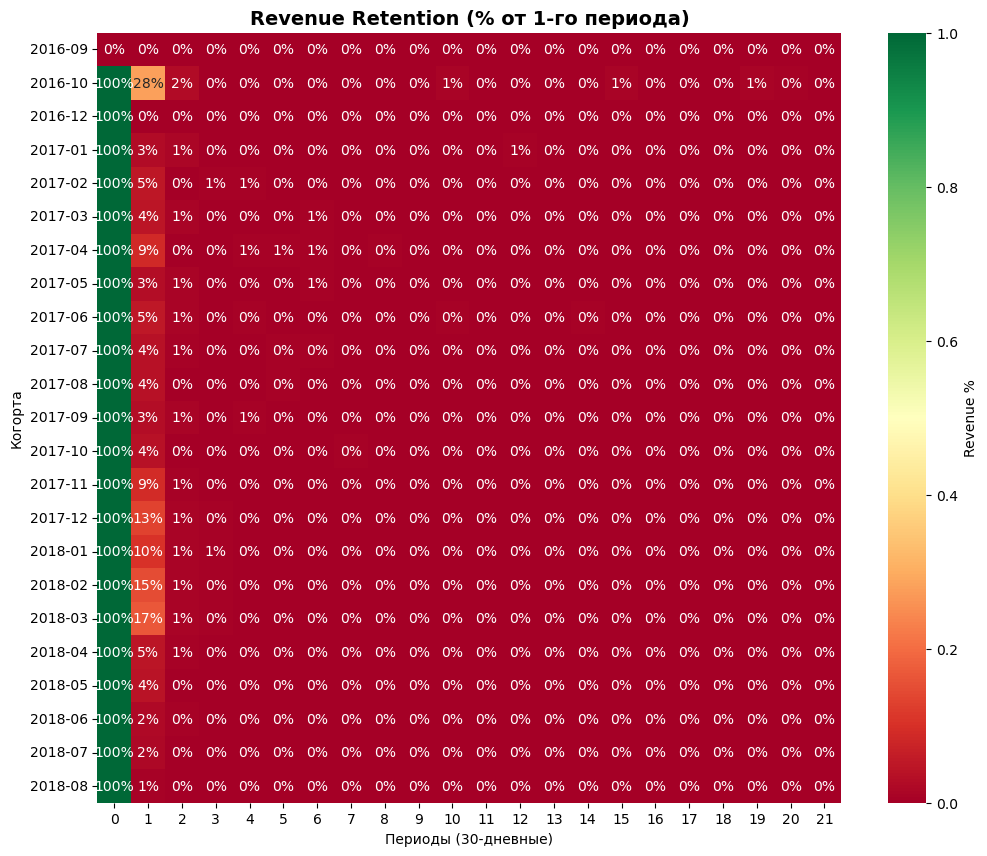

In [68]:
#HEATMAP: Revenue Retention (% от первого периода)
plt.figure(figsize=(12,10))
sns.heatmap(
    revenue_pivot.divide(revenue_pivot.iloc[:, 0], axis=0).fillna(0),
    annot=True, fmt='.0%', cmap='RdYlGn', cbar_kws={'label': 'Revenue %'},
)
plt.title('Revenue Retention (% от 1-го периода)', fontsize=14, fontweight='bold')
plt.xlabel('Периоды (30-дневные)')
plt.ylabel('Когорта')

Text(158.22222222222223, 0.5, 'Когорта')

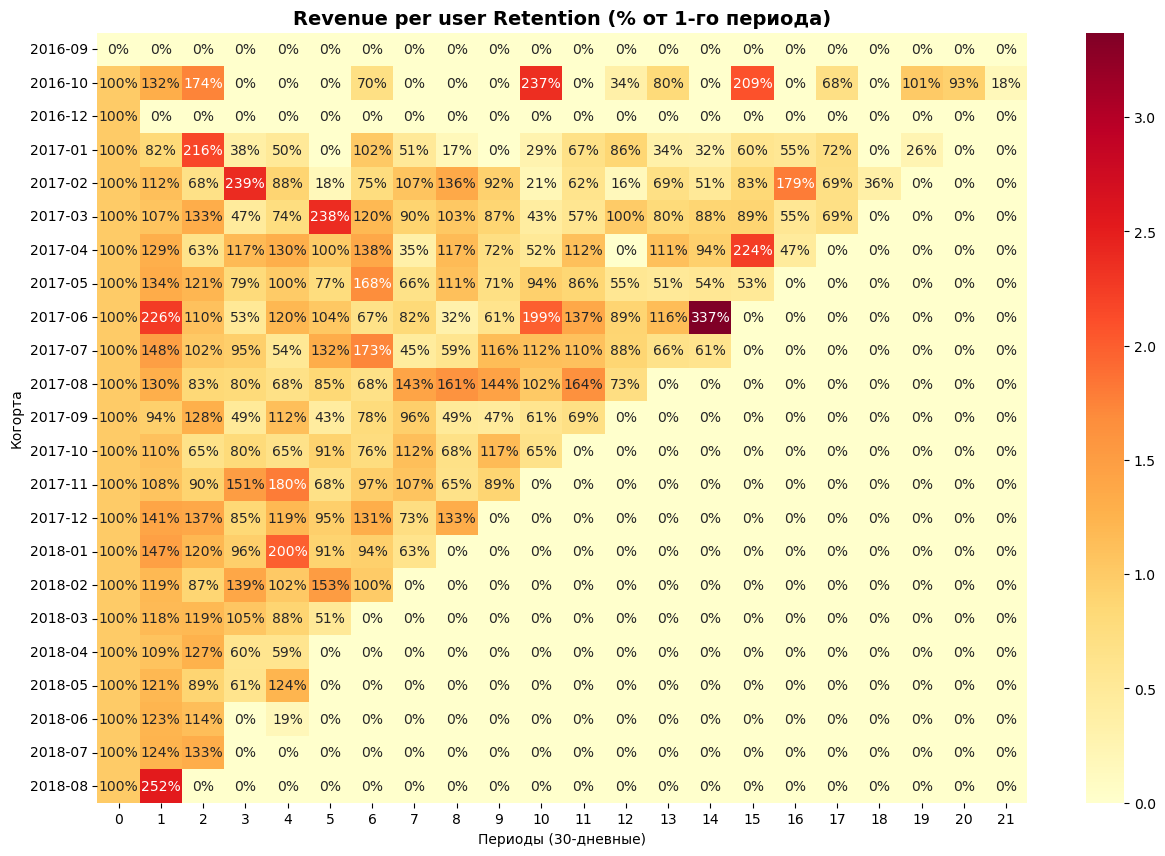

In [69]:
plt.figure(figsize=(15,10))
plt.xticks()
sns.heatmap(revenue_per_user_pivot.divide(revenue_per_user_pivot.iloc[:, 0], axis=0).fillna(0),
            annot=True, cmap='YlOrRd',fmt='.0%')
plt.title('Revenue per user Retention (% от 1-го периода)', fontsize=14, fontweight='bold')
plt.xlabel('Периоды (30-дневные)')
plt.ylabel('Когорта')

Интересную ситуацию мы наблюдаем при рассмотрении выручки на клиента, мы видим рост на некоторых периодах!!!

Это означает, что те клиенты, что возрващаются в продукт заказывают товаров на сумму либо приближённую к начальной, либо готовы вкладываться в дальнейшие заказы

# Задача 4. Выбрать одну из 3 основных гипотез с помощью фреймворка ICE.

#retention = 0.003401360544217687

Для расчёта Impact возьмите данные с июня 2017 года. Считайте, что конверсия в повторный заказ равна величине медианного retention 1-го месяца (см. пункт 1 проекта).

Гипотеза 1 - Если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен.

In [70]:
df_for_impact = orders[orders['order_purchase_timestamp'] >= '2017-06-01']
retention_1 = 0.003401360544217687 
df_for_impact.query('order_status == "unavailable"').shape[0]
#Impact == 4 

475

In [71]:
orders.order_status.value_counts('normalize')

order_status
delivered      0.970203
shipped        0.011132
canceled       0.006285
unavailable    0.006124
invoiced       0.003158
processing     0.003027
created        0.000050
approved       0.000020
Name: proportion, dtype: float64

Если мы устраним проблемы в системе процессинга, то избежим ситуаций отмены со стороны заказчика

Увеличение количества заказов соответствует значению 4 по нашей шкале 

Гипотеза 2 - Если сократим время до отгрузки заказа, то клиенты перестанут получать свой заказ с запаздыванием, вследствие чего количество заказов увеличится за счёт повторных заказов. 

Итак, найдём количество заказов которые мы получим, если люди получившие заказ с опозданием начнут делать повторные заказы

Способ 1: Мы найдём количчество заказов с опозданиями и считаем что 3.4 % из них повторяться

In [72]:
df_for_impact.query('order_estimated_delivery_date < order_delivered_customer_date ').shape[0] * retention_1
#Impact == 1

24.816326530612244

Способ 2: Мы найдём количество клиентов с проблемой опоздания, возьмём среднее количество заказов в этой группе пользователей 
и возьмём за увеличение метрики процент Retention 

In [73]:
customers_late_orders = customers_orders.query('order_estimated_delivery_date < order_delivered_customer_date ').groupby('customer_unique_id').order_id.nunique().mean()

In [74]:
customers_orders.query('order_estimated_delivery_date < order_delivered_customer_date ').customer_unique_id.nunique() \
* customers_late_orders * retention_1
#Impact == 1

np.float64(26.622448979591837)

Гипотеза 3 - Если создадим новый способ оплаты, который будет конвертировать клиентов в повторный заказ, то клиенты не будут испытывать трудности при оформлении заказа, вследствие чего количество заказов увеличится за счёт повторных заказов тех, кто раньше не делал повторный заказ.

In [75]:
customers_1_o = customers_orders.groupby('customer_unique_id',as_index=False).order_id.nunique().query('order_id == 1').shape[0]
#Количество клиентов с одним заказом

In [76]:
customers_1_o * retention_1
#Impact == 3 

316.6632653061224

ИТОГ:
1. ICE 1 гипотезы = 192
2. ICE 2 гиптезы = 40
3. ICE 3 гипотезы = 135

1 гипотеза побеждает!

# Задача 5. Сформулировать нужные метрики, на которые ваша гипотеза должна повлиять.

    1. Целевая метрика - Доля доставленных заказов 

Главной задачей новвоведения является доходимость заказов до конечного потребителя, поэтому целевой метрикой будет доля доставленных заказов. Но на эту метрику могут повлиять и другие факторы, к примеру отмены самих пользователей

    2.1 Прокси метрика - Доля отменённых заказов 

Более чувствительной метрикой будет доля отменённых заказов, так мы увидим то, сработало ли изменение. Уменьшение доли отменённых заказов в свою очередь положительно коррелирует с долей доставленных заказов

    2.2 Прокси метрика - Доходимость до этапа доставки

Для более глубокого рассмотрения и увеличения чувствительности мы можем анализировать "доходимость" товара по этапам доставки, смотреть на каком моменте заказ стал недоступен для доставки, и смогли ли мы уменьшить количество "застрявших" товаров на разных этапах доставки. 


    3.1 guardrail метрика - Количество обращений в поддержку 

А вот увеличение количества обращений в поддержку будет показывать то, что в нашем изменении что-то произошло не так

    3.2 guardrail метрика - Среднее время доставки/обработки заказа 

Также при увеличении этой метрики мы поймём, что изменение было негативынм и замедлило срок доставки товаров 


# Задача 6.

# Отчёт

При проведении анализа продукта мы выявили несколько проблем:

1. Клиенты не возвращаются в продукт.

Полный и когортный анализы показали то, что клиенты не возвращаются в продукт после первого месяца использования. 
Разбор по Штатам и продавцам также не показал значительного отклонения, а значит проблема глобальная. 

Уход клиентов приводит к тому, что затраты на привлечение пользователей будут только расти, и в дальнейшем (если этот момент уже не наступил) проект не будет приносить прибыль.

Это мы можем видеть на имеющихся данных месячной выручки: хоть продукт показывал достаточно стремительный рост, рост этот был обеспечен растущим объёмом привлечённых клиентов. После оттока привлечённых пользователей выручка упала критически низко. Этого могло не произойти, если бы продукт "удерживал" уже привлечённых пользователей и формировал их лояльность. 

Это также подтверждается достаточно высокой выручкой на клиента, те пользователи что продолжали использовать продукт дальше показывали либо незначительный спад, либо рост выручки. Удержание пользователей - главный приоритет.  

Настоятельная рекомендация - создать систему лояльности в продукте, работать с "затухающими" и "ушедшими" пользователями. Сбор обратной связи 

2. Время доставки

Большинство заказов досталвяются за 6 - 15 дней, по сравнению с гигантами типа "Wildberries","Ozon" и "Яндекс маркет" это огромное время доствки. Клиенты будут выбирать тот сервис, что сможет доставить заказ быстрее. 

Для корректных рекомендаций небходимо глубокое погружиение в специфику бизнеса и внутреннего устройства процессов компании. 

Рекомендация - Ускорение процессов в логистических центрах, складах. 

3. Доля технически отменённых заказов 

Хоть отмены со стороны компании не так часты, сам факт их существования может негативно сказаться на имидже компании и лояльности клиентов.

Рекомендация по устранению проблемы была сфорулирована выше 

